# Handwriting Recognition via ANN
This small notebook aims at solving the well-knows\n ANN demo: multiclass classification of hand-written digits, using the classic MNIST dataset.

## Dataset analisys and cleaning
The dataset was downloaded from kaggle.com. The training set consists of 60.000 28x28 greyscale images. The testing set is similar, but contains 10.000 images.
The original format is UBYTE-IDX3, and was parsed into an appropriate numpy array via a custom-made function available in ubyte_idx_reader.py.

In [18]:
#IMPORT DEPENDANCES
from DATA.ubyte_idx_reader import Mnistreader
import torch
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import random
import numpy as np
import torch.nn.functional as F
from time import time

### Device check and selection

In [19]:
#check for CUDA availability for Torch and check the correct device is selected
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### Random seed setting for reproducibility

In [20]:
#SEED SETTING
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
torch.cuda.manual_seed_all(GLOBAL_SEED)

## Pytorch wrappers & initialization
The Mnistreader custom class reads the files well, but Pytorch only speaks Tensors, Datasets and Dataloaders. Let's implement Dataset correctly in order to link Pytorch to our dataset:

In [21]:
from dataset import Dataset
#custom dataset class, implements the methods required by pytorch
"""
class Dataset:

    def __init__(self, set_path=None, labels_path=None): #initializes the dataset instance with the actual data from the Mnistreader library
        self.data = Mnistreader(set_path).data
        self.labels = Mnistreader(labels_path).data
        
    def __len__(self):          #returns the size of the data
        return  len(self.data)
        
    def __getitem__(self, idx): #returns a single element in a (point, label) tuple, given the index
        return(torch.tensor(self.data[idx], dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long))
        #NB: if ANY feature processing was to be done, it should be done here on query, NOT on the entire dataset, to take advantage of asyncronous operations.

"""

'\nclass Dataset:\n\n    def __init__(self, set_path=None, labels_path=None): #initializes the dataset instance with the actual data from the Mnistreader library\n        self.data = Mnistreader(set_path).data\n        self.labels = Mnistreader(labels_path).data\n\n    def __len__(self):          #returns the size of the data\n        return  len(self.data)\n\n    def __getitem__(self, idx): #returns a single element in a (point, label) tuple, given the index\n        return(torch.tensor(self.data[idx], dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long))\n        #NB: if ANY feature processing was to be done, it should be done here on query, NOT on the entire dataset, to take advantage of asyncronous operations.\n\n'

## Hyperparameters
We define all the necessary parameters here, so it's easier to experiment:

In [22]:
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-3
NUM_WORKERS = 0 #number of data loading subprocesses. Small dataset, BP=0. If the dataset was larger, we could set this to a higher number to speed up data loading.

We now need to create our Dataset combined with an instance of the Dataloader class to help us with batching, asyncronous loading of data into the VRAM and random shuffling:

_NB: Dataset class was moved to separate .py file due to windows' inability to multi-thread in .ipynb files._


In [23]:
train_set_path = "DATA/train-images.idx3-ubyte"
train_labels_path = "DATA/train-labels.idx1-ubyte"

train_d = Dataset(train_set_path, train_labels_path)
train_dataloader = DataLoader(train_d, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)


test_set_path = "DATA/t10k-images.idx3-ubyte"
test_set_labels = "DATA/t10k-labels.idx1-ubyte"

test_d = Dataset(test_set_path, test_set_labels)
test_dataloader = DataLoader(test_d, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)

## Neural Network instancing
In Pytorch, NNs are defined by subclassing nn.Module.

Layers are defined inside the constructor (__init__).

The forward() method is needed to define the feed operations: layer by layer, with appropriate non-linear functions. We will use the "vanilla" definition, and later use nn.Sequential to compact things up.

In [24]:
class NeuralNetwork(nn.Module):
    def __init__(self): #init contains the weights.
        super().__init__()
        self.flatten = nn.Flatten() #useful to have N-dim inputs flattened automatically during the forward pass

        #TODO convert in nn.Sequential to understand how it works
        self.l1 = nn.Linear(28*28,14*28)
        self.l2 = nn.Linear(14*28,14*14)
        self.l3 = nn.Linear(14*14, 7*14)
        self.l4 = nn.Linear(7*14, 7*7)
        self.l5 = nn.Linear(7*7,10)

    def forward(self, x):  #forward contains the operations to be performed on the instanced weights.
        #Operations need to be written IN ORDER.
        #forward needs to return logits, then other functions will use the appropriate loss.
        x = self.flatten(x) #flatten input
        x = self.l1(x);     #1st layer
        x = F.relu(x)       #act. function
        x = self.l2(x);     #...
        x = F.relu(x)
        x = self.l3(x);
        x = F.relu(x)
        x = self.l4(x);
        x = F.relu(x)
        x = self.l5(x);
        return x            #output

Let's instance the NN, load it into the GPU and see if the structure is the one we wanted:

In [25]:
model = NeuralNetwork().to(device) #instance the NN and load it into memory (preferably VRAM)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (l1): Linear(in_features=784, out_features=392, bias=True)
  (l2): Linear(in_features=392, out_features=196, bias=True)
  (l3): Linear(in_features=196, out_features=98, bias=True)
  (l4): Linear(in_features=98, out_features=49, bias=True)
  (l5): Linear(in_features=49, out_features=10, bias=True)
)


Let's now define the loss and the optimizer. We'll use SGD for now, and move later to ADAM.

In [26]:
loss_fn = nn.CrossEntropyLoss() #loss function for multi-class classification
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE) #optimizer, with the model's parameters and a (fixed for now)learning rate

## Training loop!
We now setup the training loop.'

LO LO GRA BA S!

logits -> loss -> grad reset -> backward -> step

In [27]:
train_losses = []
val_losses = []
train_start = time()
for e in range(EPOCHS):
    epoch_start = time()

    epoch_train_loss,epoch_val_loss = 0,0

    #---TRAINING---

    for x,y in train_dataloader: #NB: the dataloader is an iterator, it will give us BATCH_SIZE number of elements each epoch.
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = loss_fn(logits,y)
        epoch_train_loss+=loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_losses.append(epoch_train_loss/len(train_dataloader)) #append to final loss array the average train loss for this epoch
    
    #---EVALUATION---
    model.eval()                        #set pytorch to eval mode - no dropout, batchnorm layer active. Useless here but good practice.
    with torch.no_grad():               #tell pytorch to not build computational graph for efficient backprop, unneedded in eval. with is used to avoid calculating gradients.
        for x, y in test_dataloader:        #eval loop
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = loss_fn(logits,y)
            epoch_val_loss+=loss.item()
        val_losses.append(epoch_val_loss/len(test_dataloader)) #append to final loss array the average validation loss for this epoch
    
    model.train()   #undo model.eval()

    print('EPOCH ' +str(e)+"/"+str(EPOCHS)+ ' LOSS: '+ str('%.4f'%train_losses[-1]) + ' TIME: ' + str('%.2f'%((time()-epoch_start))) + "sec")
print("TOTAL TRAIN TIME: " + str('%.2f'%((time()-train_start))) + "sec")

EPOCH 0/50 LOSS: 0.3831 TIME: 4.29sec
EPOCH 1/50 LOSS: 0.1695 TIME: 4.21sec
EPOCH 2/50 LOSS: 0.1272 TIME: 4.37sec
EPOCH 3/50 LOSS: 0.0999 TIME: 4.15sec
EPOCH 4/50 LOSS: 0.0817 TIME: 4.18sec
EPOCH 5/50 LOSS: 0.0687 TIME: 4.15sec
EPOCH 6/50 LOSS: 0.0575 TIME: 4.18sec
EPOCH 7/50 LOSS: 0.0485 TIME: 4.28sec
EPOCH 8/50 LOSS: 0.0408 TIME: 4.25sec
EPOCH 9/50 LOSS: 0.0348 TIME: 4.31sec
EPOCH 10/50 LOSS: 0.0290 TIME: 4.01sec
EPOCH 11/50 LOSS: 0.0247 TIME: 4.05sec
EPOCH 12/50 LOSS: 0.0209 TIME: 4.17sec
EPOCH 13/50 LOSS: 0.0174 TIME: 4.74sec
EPOCH 14/50 LOSS: 0.0147 TIME: 4.14sec
EPOCH 15/50 LOSS: 0.0123 TIME: 4.14sec
EPOCH 16/50 LOSS: 0.0106 TIME: 4.08sec
EPOCH 17/50 LOSS: 0.0088 TIME: 4.11sec
EPOCH 18/50 LOSS: 0.0078 TIME: 4.64sec
EPOCH 19/50 LOSS: 0.0064 TIME: 4.11sec
EPOCH 20/50 LOSS: 0.0055 TIME: 4.38sec
EPOCH 21/50 LOSS: 0.0049 TIME: 4.22sec
EPOCH 22/50 LOSS: 0.0042 TIME: 4.35sec
EPOCH 23/50 LOSS: 0.0037 TIME: 4.24sec
EPOCH 24/50 LOSS: 0.0032 TIME: 4.31sec
EPOCH 25/50 LOSS: 0.0029 TIME: 4.30

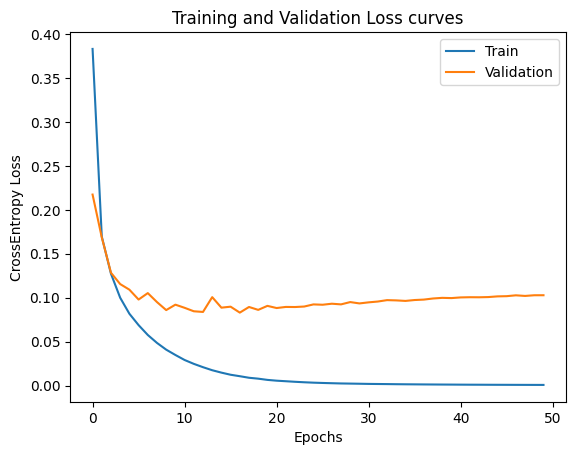

In [28]:
plt.plot(train_losses)
plt.plot(val_losses)
plt.xlabel('Epochs')
plt.ylabel('CrossEntropy Loss')
plt.title('Training and Validation Loss curves')
plt.legend(['Train', 'Validation'])
plt.show()